## Assignment 3: Data Collection and Prep
## Othmane Kerfal

In [27]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

# data mining
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


# visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
import seaborn as sns

# Data input method and Preparations 

In [7]:
house = pd.read_csv("./house_sales.csv") #read data file
house

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
0,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
1,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
2,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
3,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
4,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22682,2011-04-08,325000,9842300710,Single Family,2011-04-01,318700,0.732307,443803.0,1,5468,...,1.75,3,7,1951,0,0,201000,172000,98126,False
22683,2007-09-28,1580000,9845500010,Single Family,2007-09-01,433500,0.996094,1586196.0,1,23914,...,4.50,4,11,2000,0,1,703000,951000,98040,False
22684,2012-07-09,165000,9899200010,Single Family,2012-07-01,325300,0.747472,220744.0,1,11170,...,1.00,4,6,1971,0,0,92000,130000,98055,False
22685,2006-05-26,315000,9900000355,Single Family,2006-05-01,400600,0.920496,342207.0,1,6223,...,2.00,3,7,1939,0,0,103000,212000,98166,False


In [8]:
house.head(10) #see the first 10 items in the data file 

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
0,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
1,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
2,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
3,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
4,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False
5,2009-03-30,349900,3600090,Townhouse,2009-03-01,369800,0.849724,411781.0,1,1012,...,1.50,2,8,2008,0,0,170000,207000,98144,True
6,2013-08-28,327500,3800004,Single Family,2013-08-01,374300,0.860064,380785.0,1,34465,...,1.50,3,8,1961,0,0,165000,227000,98178,False
7,2007-05-24,347000,3800009,Single Family,2007-05-01,432100,0.992877,349489.0,1,14659,...,1.75,4,7,1963,0,0,115000,154000,98178,False
8,2006-09-22,220400,6600055,Single Family,2006-09-01,414800,0.953125,231239.0,1,5324,...,1.00,2,6,1930,0,3,90000,75000,98032,False
9,2006-08-22,437500,7200080,Multiplex,2006-08-01,411100,0.944623,463148.0,2,10585,...,2.00,4,6,1924,0,0,124000,116000,98055,False


In [9]:
house.shape # to see number of columns and rows

(22687, 22)

In [10]:
house.info() #see all items in data file and what type they are

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22687 entries, 0 to 22686
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DocumentDate     22687 non-null  object 
 1   SalePrice        22687 non-null  int64  
 2   PropertyID       22687 non-null  int64  
 3   PropertyType     22687 non-null  object 
 4   ym               22687 non-null  object 
 5   zhvi_px          22687 non-null  int64  
 6   zhvi_idx         22687 non-null  float64
 7   AdjSalePrice     22687 non-null  float64
 8   NbrLivingUnits   22687 non-null  int64  
 9   SqFtLot          22687 non-null  int64  
 10  SqFtTotLiving    22687 non-null  int64  
 11  SqFtFinBasement  22687 non-null  int64  
 12  Bathrooms        22687 non-null  float64
 13  Bedrooms         22687 non-null  int64  
 14  BldgGrade        22687 non-null  int64  
 15  YrBuilt          22687 non-null  int64  
 16  YrRenovated      22687 non-null  int64  
 17  TrafficNoise

In [11]:
house.describe()

,SalePrice,PropertyID,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,SqFtTotLiving,SqFtFinBasement,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode
count,2.268700e+04,2.268700e+04,22687.000000,22687.000000,2.268700e+04,22687.000000,2.268700e+04,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,2.268700e+04,2.268700e+04,22687.000000
mean,5.079244e+05,4.666164e+09,392181.923569,0.901153,5.652333e+05,1.018821,1.174633e+04,2080.165734,293.233305,2.176500,3.367744,7.680963,1971.195266,102.314762,0.205801,2.203211e+05,3.004712e+05,98078.526910
std,3.466368e+05,2.877700e+09,36349.866645,0.083525,3.854029e+05,0.159752,2.901602e+04,913.742170,439.454608,0.768027,0.904379,1.180464,30.313796,440.579006,0.554216,1.829177e+05,2.265750e+05,52.342559
min,3.000000e+03,1.000102e+06,311600.000000,0.715993,3.368000e+03,1.000000,4.940000e+02,370.000000,0.000000,0.000000,0.000000,3.000000,1900.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98001.000000
25%,3.250000e+05,2.212325e+09,360700.000000,0.828814,3.605630e+05,1.000000,4.800000e+03,1420.000000,0.000000,1.750000,3.000000,7.000000,1950.000000,0.000000,0.000000,1.070000e+05,1.720000e+05,98034.000000
50%,4.246500e+05,4.006000e+09,403200.000000,0.926471,4.713150e+05,1.000000,7.200000e+03,1910.000000,0.000000,2.250000,3.000000,7.000000,1977.000000,0.000000,0.000000,1.820000e+05,2.460000e+05,98065.000000
75%,5.850000e+05,7.417700e+09,421200.000000,0.967831,6.494110e+05,1.000000,9.794000e+03,2540.000000,580.000000,2.500000,4.000000,8.000000,2000.000000,0.000000,0.000000,2.670000e+05,3.610000e+05,98117.000000
max,1.100000e+07,9.906000e+09,435200.000000,1.000000,1.164486e+07,5.000000,1.024068e+06,10740.000000,3500.000000,8.000000,33.000000,13.000000,2015.000000,2016.000000,3.000000,5.538000e+06,5.772000e+06,98354.000000


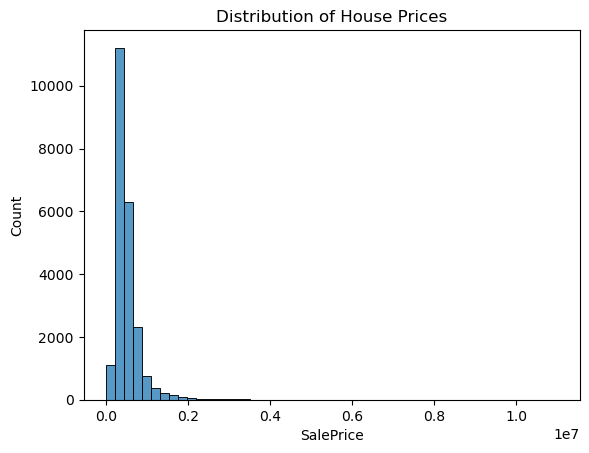

In [12]:
plt.figure()
sns.histplot(house['SalePrice'], bins=50)
plt.title("Distribution of House Prices")
plt.show() #see the distribution of house prices

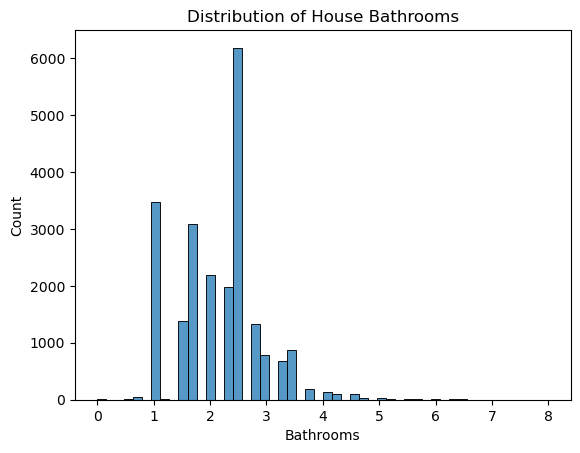

In [13]:
plt.figure()
sns.histplot(house['Bathrooms'], bins=50)
plt.title("Distribution of House Bathrooms")
plt.show() # show how many bathrooms each house has

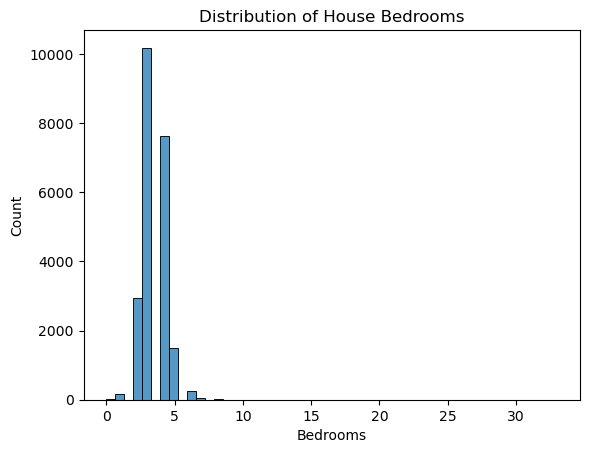

In [14]:
plt.figure()
sns.histplot(house['Bedrooms'], bins=50)
plt.title("Distribution of House Bedrooms")
plt.show()# show how many bedrooms each house has

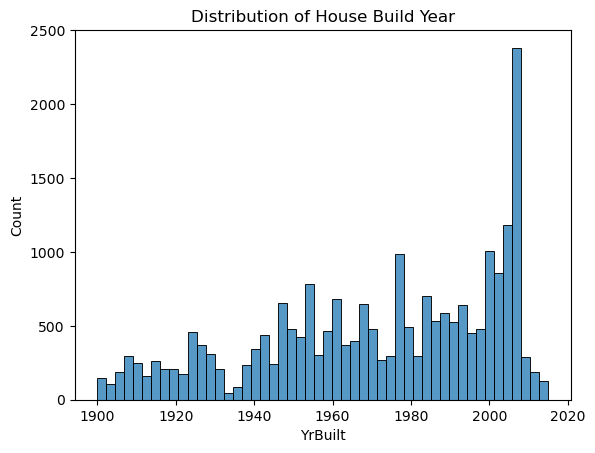

In [15]:
plt.figure()
sns.histplot(house['YrBuilt'], bins=50)
plt.title("Distribution of House Build Year")
plt.show() #see when each house was built

# Data modeling methods 

In [16]:
# The data I have are the price of housing, number of bedrooms, number of bathrooms, and the year of when each house was built.
# I want to see how each variable effects the price of the house.

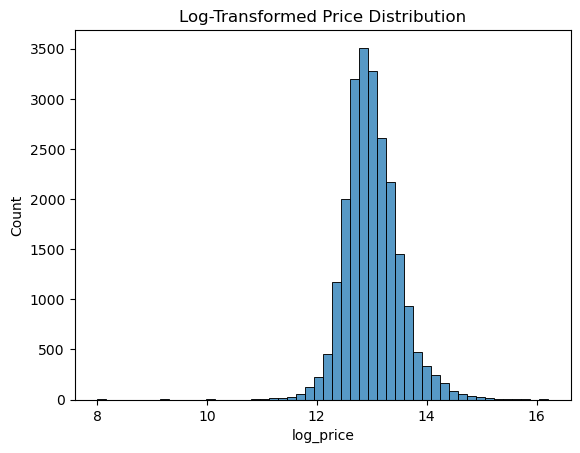

In [17]:
house['log_price'] = np.log(house['SalePrice'])
sns.histplot(house['log_price'], bins=50)
plt.title("Log-Transformed Price Distribution")
plt.show() #finding the distribution of house prices using logarithmic for price

In [18]:
house = house[house['Bedrooms'] < 10]
house = house[house['Bathrooms'] < 8]
house['log_price'] = np.log(house['SalePrice']) # to get rid of outliers of more than 10 bedrooms and 8 bathrooms

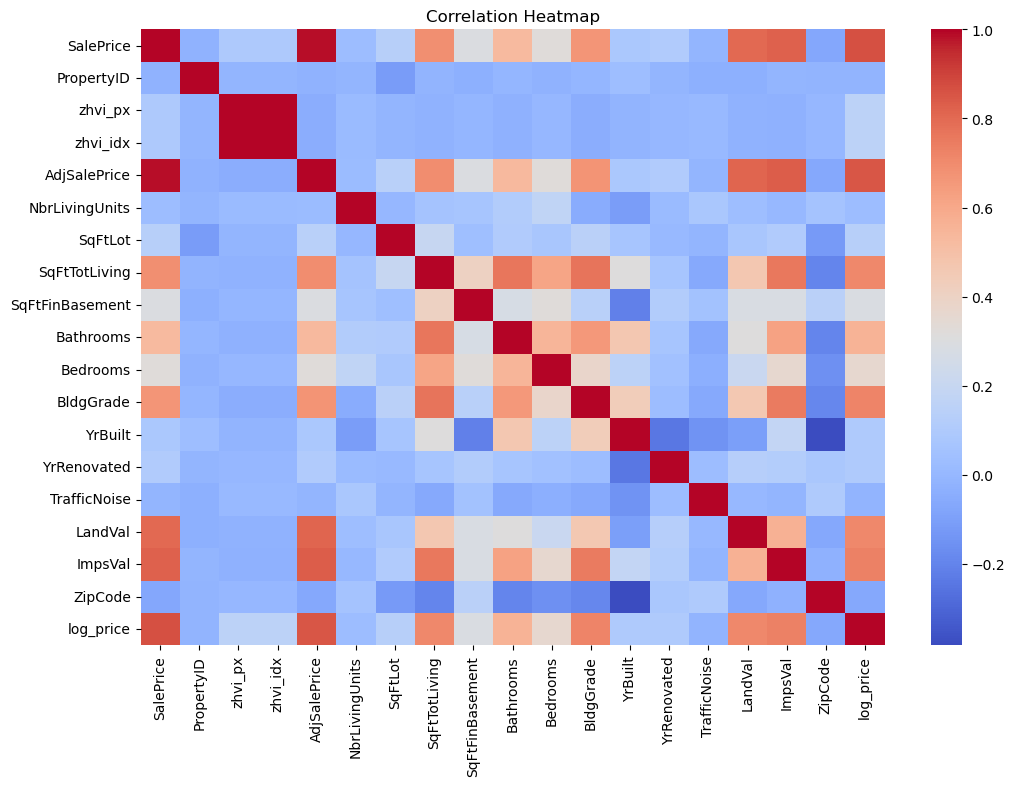

In [19]:
numeric_house = house.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_house.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show() #heatmap to see which factor has the biggest impact on sales price

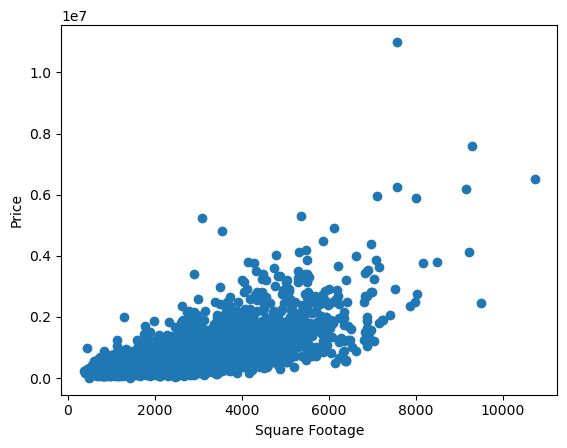

In [20]:
plt.scatter(house['SqFtTotLiving'], house['SalePrice'])
plt.xlabel("Square Footage")
plt.ylabel("Price")
plt.show() #scatterplot to see relationship between square footage and sales price

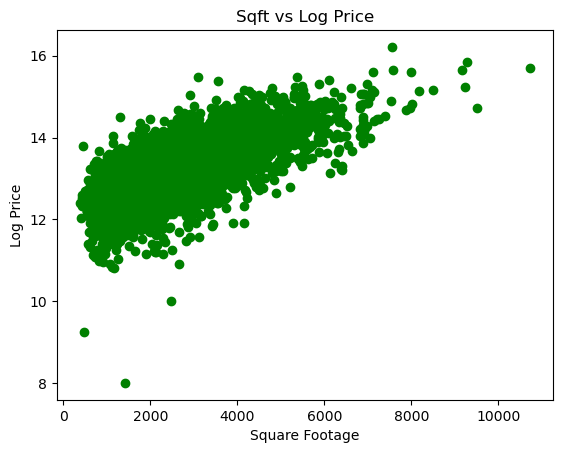

In [21]:
house['log_price'] = np.log(house['SalePrice'])

plt.scatter(house['SqFtTotLiving'], house['log_price'],c='green')
plt.xlabel("Square Footage")
plt.ylabel("Log Price")
plt.title("Sqft vs Log Price")
plt.show() #scatter plot to square footage and sales price correlation in log

# Model evaluation method

In [22]:
house['SqFtTotLiving'].corr(house['SalePrice']) #to see 

np.float64(0.6908699370743143)

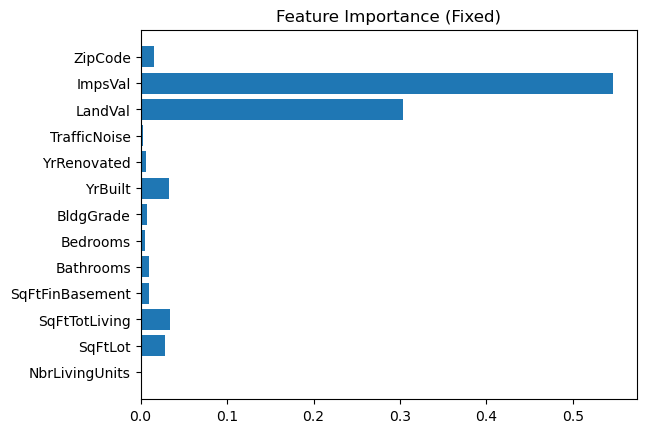

In [32]:
X = numeric_house.drop([
    'SalePrice',
    'log_price',
    'AdjSalePrice',   
    'PropertyID',   
    'zhvi_px',        
    'zhvi_idx'        
], axis=1)

y = numeric_house['log_price']

rf = RandomForestRegressor()
rf.fit(X, y)

importance = rf.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance (Fixed)")
plt.show() #To see which factor impacts price 

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)

print("RMSE:", rmse) #train test to test model vs actual price of each house

0.20717610484986337


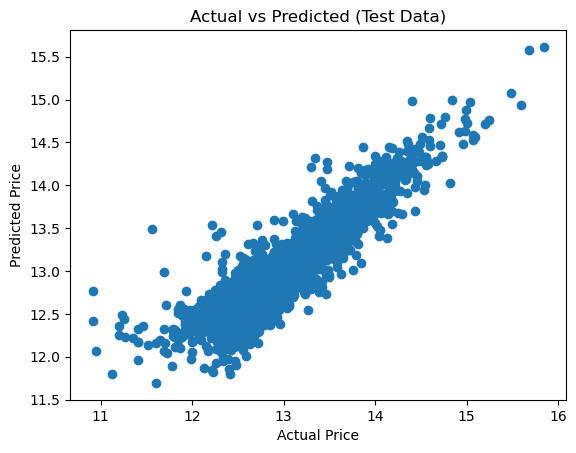

In [38]:
plt.scatter(y_test, preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Test Data)")
plt.show() #showing predicted vs actual house price